In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import lfilter, freqz

## FIR Filters

### Direct Implementation From The Difference Equation

The equation is found in: https://ringbuffer.org/dsp/Digital_Filters/fir-filters/

$$
y[n] = \sum\limits_{i=0}^{N} b_i \cdot x[n-i]
$$

In [2]:
# Direct Implementation Functions
def fir_filter_direct(x, h):
    
    N = len(x)
    M = len(h)
    y = np.zeros(N)
    
    ## This is just the convolution function
    for n in range(N):
        for k in range(M):
            if n - k >= 0:
                y[n] += h[k] * x[n - k]
    return y

In [3]:
def generate_impulse(length=50):
    """Generate impulse input signal"""
    n = np.arange(length)
    x = np.zeros_like(n)
    x[0] = 1  # impulse input
    return n, x

### Low Pass Filter
#### Time Domain Impulse Response

Text(0, 0.5, 'h[n]')

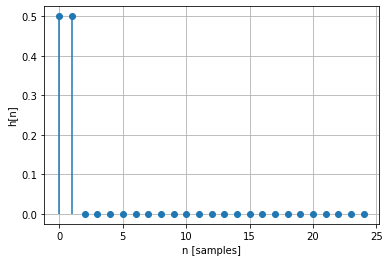

In [4]:
low_pass_fir = np.array([0.5, 0.5])

n, x = generate_impulse(25)
y = fir_filter_direct(x, low_pass_fir)

plt.stem(n, y, basefmt=" ")
plt.grid(True)
plt.xlabel('n [samples]')
plt.ylabel('h[n]')

<Figure size 1080x720 with 0 Axes>

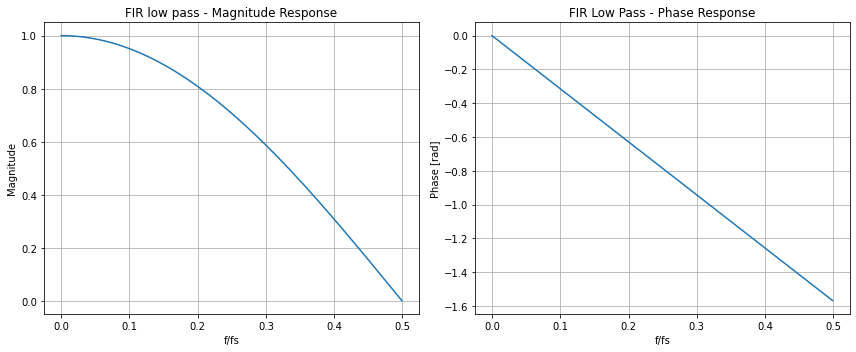

In [5]:
fig = plt.figure(figsize=(15, 10))
b, a = low_pass_fir, np.array([1.0])

w, h = freqz(b, a)
freq = w / (2 * np.pi)

plt.figure(figsize=(12, 5))

plt.subplot(121)
plt.plot(freq, np.abs(h))
plt.grid(True)
plt.xlabel('f/fs')
plt.ylabel('Magnitude')
plt.title("FIR low pass - Magnitude Response")

plt.subplot(122)
plt.plot(freq, np.angle(h))
plt.grid(True)
plt.xlabel('f/fs')
plt.ylabel('Phase [rad]')
plt.title('FIR Low Pass - Phase Response')
plt.tight_layout()
plt.show()




### Using Scipy

#### Time Domain Impulse Response


Text(0, 0.5, 'h[n]')

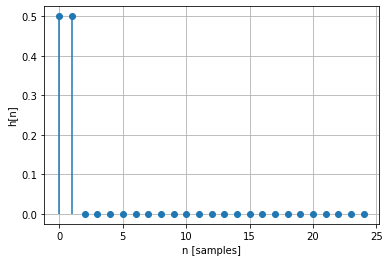

In [6]:
low_pass_fir = np.array([0.5, 0.5])
b, a = low_pass_fir, np.array([1.0])

n, x = generate_impulse(25)
y_scipy = lfilter(b, a, x)

plt.stem(n, y, basefmt=" ")
plt.grid(True)
plt.xlabel('n [samples]')
plt.ylabel('h[n]')

<Figure size 1080x720 with 0 Axes>

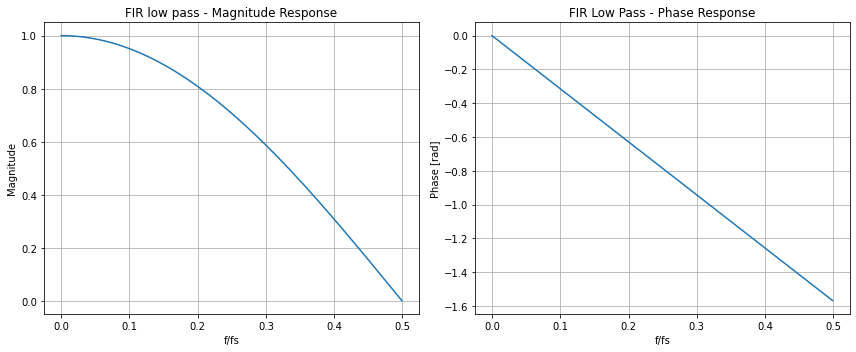

In [7]:
fig = plt.figure(figsize=(15, 10))
b, a = low_pass_fir, np.array([1.0])

w, h = freqz(b, a)
freq = w / (2 * np.pi)

plt.figure(figsize=(12, 5))

plt.subplot(121)
plt.plot(freq, np.abs(h))
plt.grid(True)
plt.xlabel('f/fs')
plt.ylabel('Magnitude')
plt.title("FIR low pass - Magnitude Response")

plt.subplot(122)
plt.plot(freq, np.angle(h))
plt.grid(True)
plt.xlabel('f/fs')
plt.ylabel('Phase [rad]')
plt.title('FIR Low Pass - Phase Response')
plt.tight_layout()
plt.show()

### Application To Noisy Sine Wave

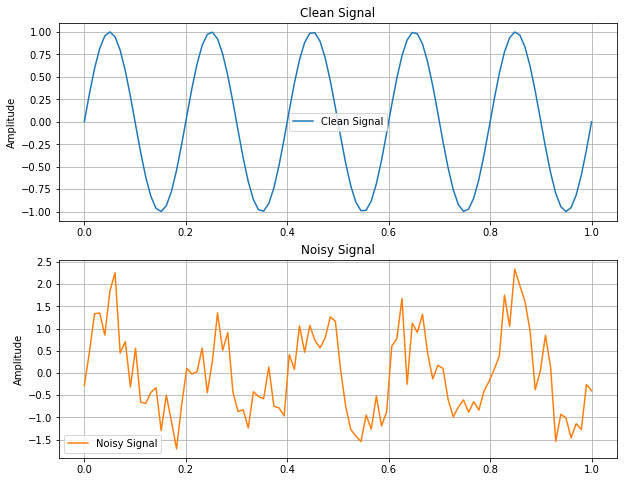

In [8]:
# Define the sampling rate in Hz
fs = 100  

# Generate sample indices and corresponding time vector in seconds
n = np.linspace(0, 1,fs)                        
# Specify frequency in Hz (for example, 5 Hz)
frequency = 5          

# Generate a clean sine wave signal using time in seconds
clean_signal = np.sin(2 * np.pi * frequency * n)

# Generate some random noise
noise = 0.5 * np.random.randn(len(n))

# Create a noisy signal by adding noise to the clean sine wave
noisy_signal = clean_signal + noise


# Plotting the results
plt.figure(figsize=(10, 8))

# Plot the clean signal
plt.subplot(2, 1, 1)
plt.plot(n, clean_signal, label='Clean Signal', color='C0')
plt.title('Clean Signal')
plt.ylabel('Amplitude')
plt.grid(True)
plt.legend()

# Plot the noisy signal
plt.subplot(2, 1, 2)
plt.plot(n, noisy_signal, label='Noisy Signal', color='C1')
plt.title('Noisy Signal')
plt.ylabel('Amplitude')
plt.grid(True)
plt.legend()

#### Applying the Filter On The Noisy Signal

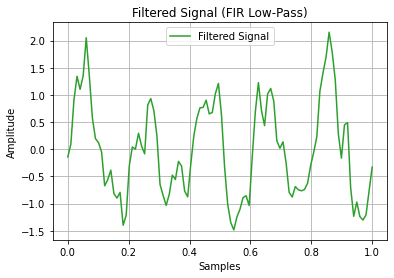

In [9]:
low_pass_fir = np.array([0.5, 0.5])
filtered_signal = fir_filter_direct(noisy_signal, low_pass_fir)

#Uncomment the bottom two lines and try it out
#b, a = low_pass_fir, np.array([1.0])
#y_scipy = lfilter(b, a, noisy_signal)

plt.plot(n, filtered_signal, label='Filtered Signal', color='C2')
plt.title('Filtered Signal (FIR Low-Pass)')
plt.xlabel('Samples')
plt.ylabel('Amplitude')
plt.grid(True)
plt.legend()

# IIR Filters

## Using the difference Equation to realize the filter

Equation is found her: https://ringbuffer.org/dsp/Digital_Filters/iir-filters/

$$
y[n] = \sum\limits_{i=0}^{N} b_i \cdot x[n-i] - \sum\limits_{i=1}^{N} a_i \cdot y[n-i]
$$

In [10]:
def iir_filter_direct(x, b, a):
    N = len(x)
    M = len(b)
    P = len(a)
    y = np.zeros(N)
    
    for n in range(N):
        # Feed-forward part
        for k in range(M):
            if n - k >= 0:
                y[n] += b[k] * x[n - k]
        
        # Feedback part
        for k in range(1, P):
            if n - k >= 0:
                y[n] -= a[k] * y[n - k]
        
        y[n] /= a[0]
    
    return y

## Low Pass Filter
#### Time Domain Impulse Response

Text(0, 0.5, 'h[n]')

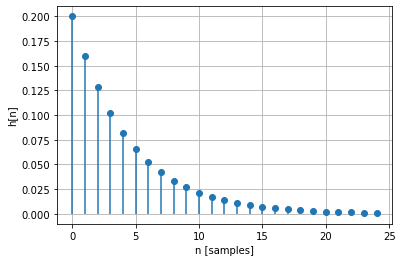

In [11]:
# IIR filters:
# First-order IIR low-pass filter (alpha = 0.8):
low_pass_iir_b = np.array([1 - 0.8])   # Numerator: [0.2]
low_pass_iir_a = np.array([1, -0.8])     # Denominator: [1, -0.8]

n, x = generate_impulse(25)

b, a = low_pass_iir_b, low_pass_iir_a
y_iir = iir_filter_direct(x, b, a)

plt.stem(n, y_iir, basefmt=" ")
plt.grid(True)
plt.xlabel('n [samples]')
plt.ylabel('h[n]')

<Figure size 1080x720 with 0 Axes>

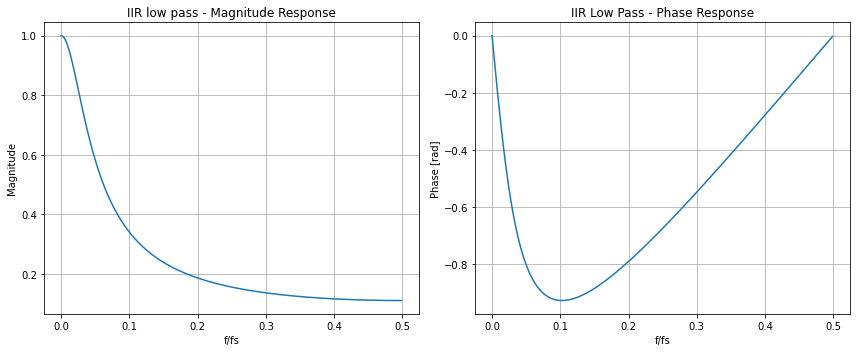

In [12]:
fig = plt.figure(figsize=(15, 10))
b, a = low_pass_iir_b, low_pass_iir_a

w, h = freqz(b, a)
freq = w / (2 * np.pi)

plt.figure(figsize=(12, 5))

plt.subplot(121)
plt.plot(freq, np.abs(h))
plt.grid(True)
plt.xlabel('f/fs')
plt.ylabel('Magnitude')
plt.title("IIR low pass - Magnitude Response")

plt.subplot(122)
plt.plot(freq, np.angle(h))
plt.grid(True)
plt.xlabel('f/fs')
plt.ylabel('Phase [rad]')
plt.title('IIR Low Pass - Phase Response')
plt.tight_layout()
plt.show()

## Using Scipy

### Low Pass Filter

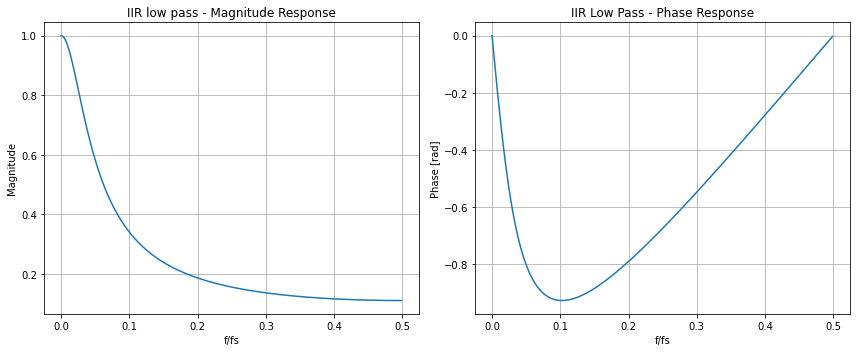

In [13]:
# IIR filters:
# First-order IIR low-pass filter (alpha = 0.8):
low_pass_iir_b = np.array([1 - 0.8])   # Numerator: [0.2]
low_pass_iir_a = np.array([1, -0.8])     # Denominator: [1, -0.8]

b, a = low_pass_iir_b, low_pass_iir_a
y_scipy = lfilter(b, a, x)

w, h = freqz(b, a)
freq = w / (2 * np.pi)

plt.figure(figsize=(12, 5))

plt.subplot(121)
plt.plot(freq, np.abs(h))
plt.grid(True)
plt.xlabel('f/fs')
plt.ylabel('Magnitude')
plt.title("IIR low pass - Magnitude Response")

plt.subplot(122)
plt.plot(freq, np.angle(h))
plt.grid(True)
plt.xlabel('f/fs')
plt.ylabel('Phase [rad]')
plt.title('IIR Low Pass - Phase Response')
plt.tight_layout()
plt.show()


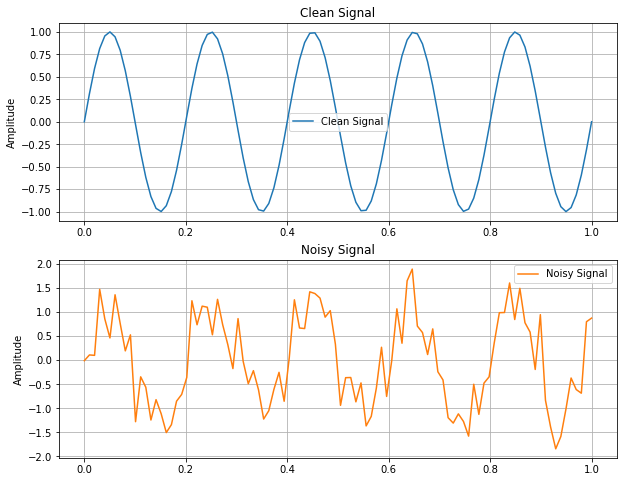

In [14]:
# Define the sampling rate in Hz
fs = 100

# Generate sample indices and corresponding time vector in seconds
n = np.linspace(0, 1,fs)                        
# Specify frequency in Hz (for example, 5 Hz)
frequency = 5          

# Generate a clean sine wave signal using time in seconds
clean_signal = np.sin(2 * np.pi * frequency * n)

# Generate some random noise
noise = 0.5 * np.random.randn(len(n))

# Create a noisy signal by adding noise to the clean sine wave
noisy_signal = clean_signal + noise


# Plotting the results
plt.figure(figsize=(10, 8))

# Plot the clean signal
plt.subplot(2, 1, 1)
plt.plot(n, clean_signal, label='Clean Signal', color='C0')
plt.title('Clean Signal')
plt.ylabel('Amplitude')
plt.grid(True)
plt.legend()

# Plot the noisy signal
plt.subplot(2, 1, 2)
plt.plot(n, noisy_signal, label='Noisy Signal', color='C1')
plt.title('Noisy Signal')
plt.ylabel('Amplitude')
plt.grid(True)
plt.legend()

### Applying the IIR filter

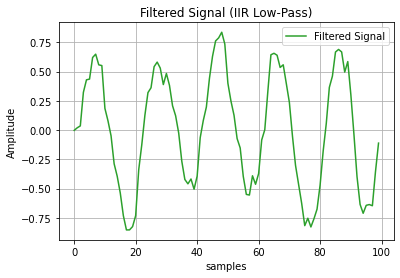

In [18]:
# IIR filters:
# First-order IIR low-pass filter (alpha = 0.8):
low_pass_iir_b = np.array([1 - 0.8])   # Numerator: [0.2]
low_pass_iir_a = np.array([1, -0.8])     # Denominator: [1, -0.8]

b, a = low_pass_iir_b, low_pass_iir_a

y_scipy = lfilter(b, a, noisy_signal)


#Uncomment the bottom two lines and try it out
# b, a = low_pass_fir, np.array([1.0])
# y_iir = iir_filter_direct(noisy_signal, b, a)

plt.plot(y_scipy, label='Filtered Signal', color='C2')
plt.title('Filtered Signal (IIR Low-Pass)')
plt.xlabel('samples')
plt.ylabel('Amplitude')
plt.grid(True)
plt.legend()

## Filters Activity

Visualize the filters based on the coefficients provided

In this activity you will realize filters using the scipy module, visualize their magnitude and phase response and apply it to a noisy signal and plot it's effects.

The functions for each operation is provided below, and the dictionary with the filter parameters

The examples for this activity are derived from: https://github.com/alexanderlerch/MUSI-6202/blob/main/matlab/plotSimpleFilter.m



In [19]:
# Dictionary of filters
FILTERS = {
    "fir": {
        "1": {
            "b":np.array([0.5, 0.5]),
            "a":np.array([1.0])
             },
        "2": {
            "b":np.array([0.5, -0.5]),
            "a":np.array([1.0]) },
        "3": {"b":np.array([0.5, 0, 0, 0, 0, -0.5]),
              "a":np.array([1.0])},
        "4": {"b":np.ones(5) / 5, "a":np.array([1.0])}
    },
    "iir": {
        "1": {
            "b": np.array([0.2]),       # Numerator
            "a": np.array([1, -0.8])    # Denominator
        },
        "2": {
            "b": np.array([0.2]),       # Numerator
            "a": np.array([1, 0.8])     # Denominator
        },
        "3": {
            "b": np.array([0.2] + [0] * 4),  # Numerator
            "a": np.array([1] + [0] * 4 + [0.8])  # Denominator
        }
    }
}

In [20]:
def plot_frequency_response(b, a, subplot_idx=None, fig=None):
    """Plot frequency response"""
    w, h = freqz(b, a)
    freq = w / (2 * np.pi)
    
    if fig is None:
        plt.figure(figsize=(12, 5))
        plt.subplot(121)
    else:
        plt.subplot(subplot_idx[0])
    
    plt.plot(freq, np.abs(h))
    plt.grid(True)
    plt.xlabel('f/fs')
    plt.ylabel('Magnitude')
    plt.title('Magnitude Response')
    
    if fig is None:
        plt.subplot(122)
    else:
        plt.subplot(subplot_idx[1])
    
    plt.plot(freq, np.angle(h))
    plt.grid(True)
    plt.xlabel('f/fs')
    plt.ylabel('Phase [rad]')
    plt.title('Phase Response')
    
    if fig is None:
        plt.tight_layout()
        plt.show()

In [21]:
def noise(fs,frequency):
    # Generate sample indices and corresponding time vector in seconds
    n = np.linspace(0, 1,fs)                                 

    # Generate a clean sine wave signal using time in seconds
    clean_signal = np.sin(2 * np.pi * frequency * n)
    
    # Generate some random noise
    noise = 0.5 * np.random.randn(len(n))

    # Create a noisy signal by adding noise to the clean sine wave
    noisy_signal = clean_signal + noise
    return noisy_signal,clean_signal

### What you will do:

Move the above functions to a new script and in the script, you will call each filter parameter from the dictionary as shown in the code below:

In [22]:
FILTERS["fir"]["3"]

{'b': array([ 0.5,  0. ,  0. ,  0. ,  0. , -0.5]), 'a': array([1.])}

#### Extract the coefficients of the filter as shown below and use them as parameters in the plot function provided, 
- try this for all the coefficients and make a best guess as to what the filters would do?
- Identify the key differences in the FIR and IIR responses

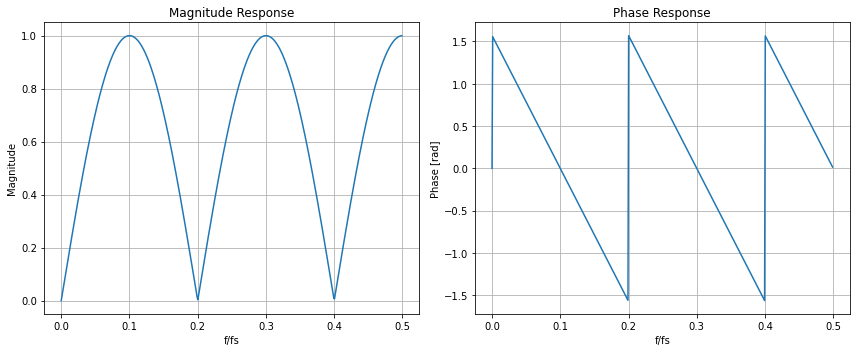

In [23]:
#extract_coefficients 
b = FILTERS["fir"]["3"]['b']
a = FILTERS["fir"]["3"]["a"]
#Plot
plot_frequency_response(b, a, subplot_idx=None, fig=None)

In [24]:
def time_plot(signal,filtered_signal):
    plt.subplot(2,1,1)
    plt.plot(signal)
    plt.title("Noisy Signal")
    plt.xlabel("Samples")
    plt.ylabel("Amplitude")
    plt.subplot(2,1,2)
    plt.plot(filtered_signal)
    plt.title("Filtered Signal")
    plt.xlabel("Samples")
    plt.ylabel("Amplitude")
    
    plt.tight_layout()
    plt.show()

#### Apply the filter effects to a noisy signal as shown below

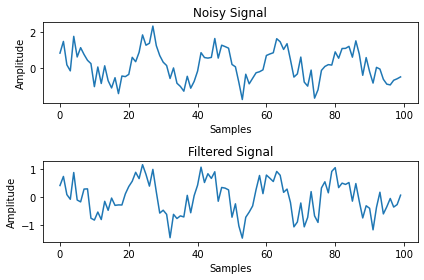

In [25]:
# Apply the filter to a noisy signal

noisy_signal,clean_signal = noise(100,5)

#extract_coefficients 
b = FILTERS["fir"]["3"]['b']
a = FILTERS["fir"]["3"]["a"]

#Apply filter
y = lfilter(b,a,noisy_signal)

time_plot(noisy_signal,y)